A regression problem refers to a type of predictive modeling task where the goal is to predict a continuous numerical output based on input features. Essentially, it's a type of supervised learning where the algorithm learns to map input variables (features) to a continuous output variable (target).

## Rental Price Prediction

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/LT_Datasets/cities_magicbricks_rental_prices.csv')
df.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0


### EDA

In [ ]:
df.shape

(7691, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   object 
 1   locality    7691 non-null   object 
 2   city        7691 non-null   object 
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   object 
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 601.0+ KB


In [ ]:
df.describe()

,area,beds,bathrooms,balconies,area_rate,rent
count,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7.691000e+03
mean,1106.354180,2.208685,2.137043,0.817319,47.619989,5.479508e+04
std,1197.426843,0.993481,1.027677,1.243361,68.989657,9.742006e+04
min,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000e+03
25%,600.000000,1.000000,1.000000,0.000000,21.000000,1.500000e+04
50%,900.000000,2.000000,2.000000,0.000000,31.000000,2.800000e+04
75%,1300.000000,3.000000,3.000000,2.000000,54.000000,5.700000e+04
max,70000.000000,10.000000,10.000000,10.000000,2586.000000,2.700000e+06


In [ ]:
# Check for null values
df.isnull().sum()

,0
house_type,0
locality,0
city,0
area,0
beds,0
bathrooms,0
balconies,0
furnishing,0
area_rate,0
rent,0


In [ ]:
# Check for duplicate rows
df.duplicated().sum()

0

In [ ]:
num_cols = ['area','area_rate','rent']
cat_cols = ['city','locality','beds','bathrooms','balconies','furnishing']

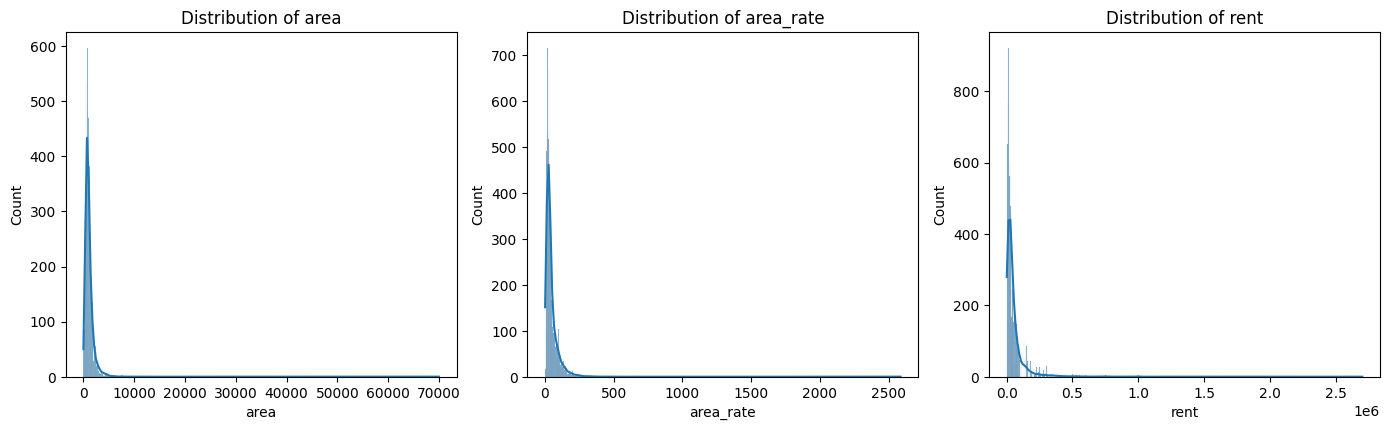

In [ ]:
# Visualizing numerical variables
plt.figure(figsize=(14, 8))
for i, column in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

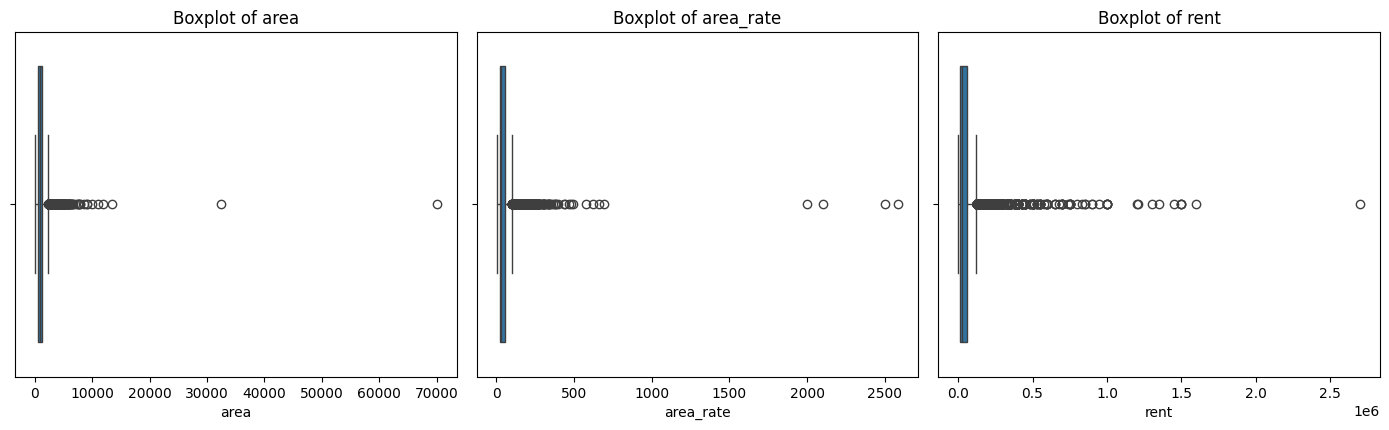

In [ ]:
# Boxplots for outlier detection
plt.figure(figsize=(14, 8))
for i, column in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=df, x=column)
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

# lots of outliers detected

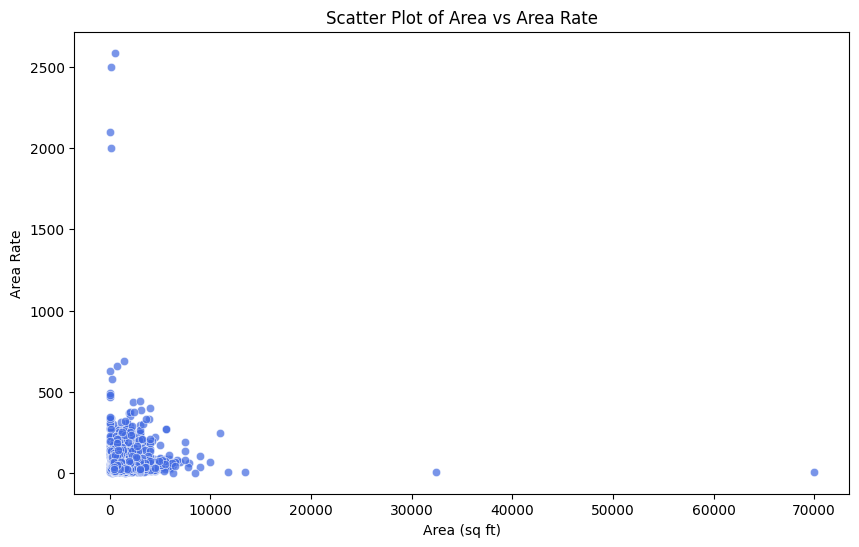

In [ ]:
# Scatter plot for area vs area_rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='area', y='area_rate', alpha=0.7, color="royalblue")
plt.title("Scatter Plot of Area vs Area Rate")
plt.xlabel("Area (sq ft)")
plt.ylabel("Area Rate")
plt.show()

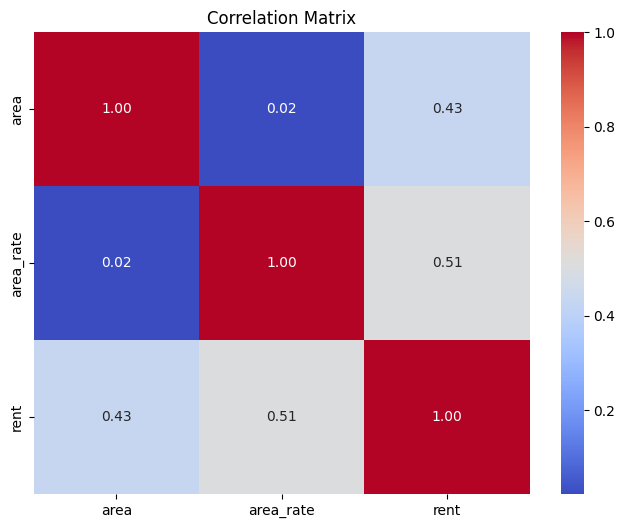

In [ ]:
# Correlation matrix
correlation_matrix = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
unique_values = {col: df[col].nunique() for col in cat_cols}
unique_values

{'city': 5,
 'locality': 1984,
 'beds': 9,
 'bathrooms': 11,
 'balconies': 10,
 'furnishing': 3}

In [ ]:
# Define your categorical columns
cat_cols = ['city', 'beds', 'bathrooms', 'balconies', 'furnishing']

# Get value counts for each categorical column
for col in cat_cols:
    print(f"Value counts for '{col}':")
    print(df[col].value_counts())
    print("\n" + "-"*40 + "\n")

Value counts for 'city':
city
New Delhi    1808
Bangalore    1790
Pune         1779
Mumbai       1719
Nagpur        595
Name: count, dtype: int64

----------------------------------------

Value counts for 'beds':
beds
2     3046
3     2035
1     1947
4      541
5       99
10       8
6        6
8        5
7        4
Name: count, dtype: int64

----------------------------------------

Value counts for 'bathrooms':
bathrooms
2     3347
1     2135
3     1517
4      453
5      180
6       33
7        9
8        8
0        7
9        1
10       1
Name: count, dtype: int64

----------------------------------------

Value counts for 'balconies':
balconies
0     5146
2     1641
3      694
4      156
5       41
6        7
10       2
7        2
9        1
8        1
Name: count, dtype: int64

----------------------------------------

Value counts for 'furnishing':
furnishing
Semi-Furnished    3428
Unfurnished       2662
Furnished         1601
Name: count, dtype: int64

--------------------------

In [ ]:
df['locality'].value_counts()

# a lot of localities are there with only a single entry

,count
locality,
Hadapsar,106
Kharadi,98
Wagholi,94
Whitefield,88
Andheri West,78
...,...
Neb Sarai Saket,1
Block 4 Subhash Nagar,1
Vikaspuri Block J,1


In [ ]:
locality_counts = df['locality'].value_counts()
# Filter localities that have only one entry
single_entry_localities = locality_counts[locality_counts == 1]

# Calculate the number and percentage of such localities
single_entry_count = single_entry_localities.sum()  # Total count of single-entry localities
total_localities = locality_counts.sum()  # Total entries in 'locality'

percentage_single_entry = (len(single_entry_localities) / len(locality_counts)) * 100

print(f"Number of localities with only one entry: {single_entry_count}")
print(f"Percentage of localities with only one entry: {percentage_single_entry:.2f}%")


Number of localities with only one entry: 1004
Percentage of localities with only one entry: 50.60%


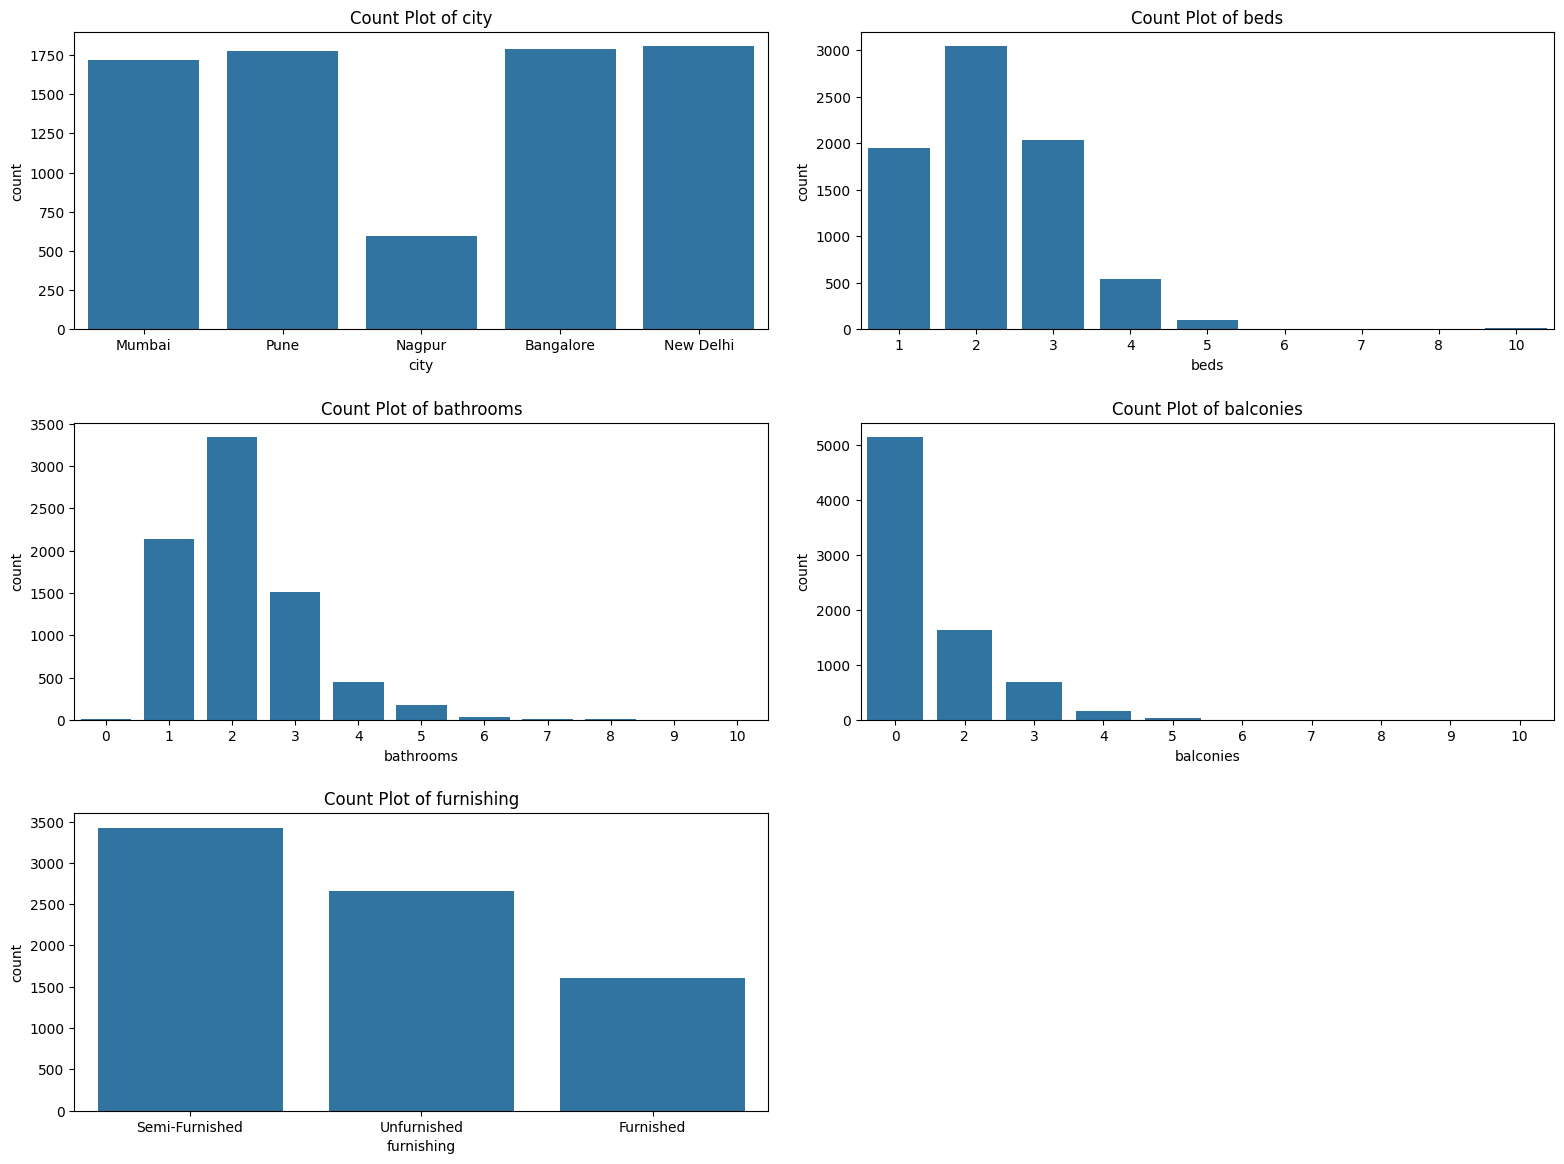

In [ ]:
cat_cols_mod = ['city','beds','bathrooms','balconies','furnishing']

plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_cols_mod, 1):
    plt.subplot(3, 2, i)  # Adjust grid layout as per the number of columns
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.tight_layout(pad=2.0)  # Adjust layout to avoid overlapping plots

plt.show()

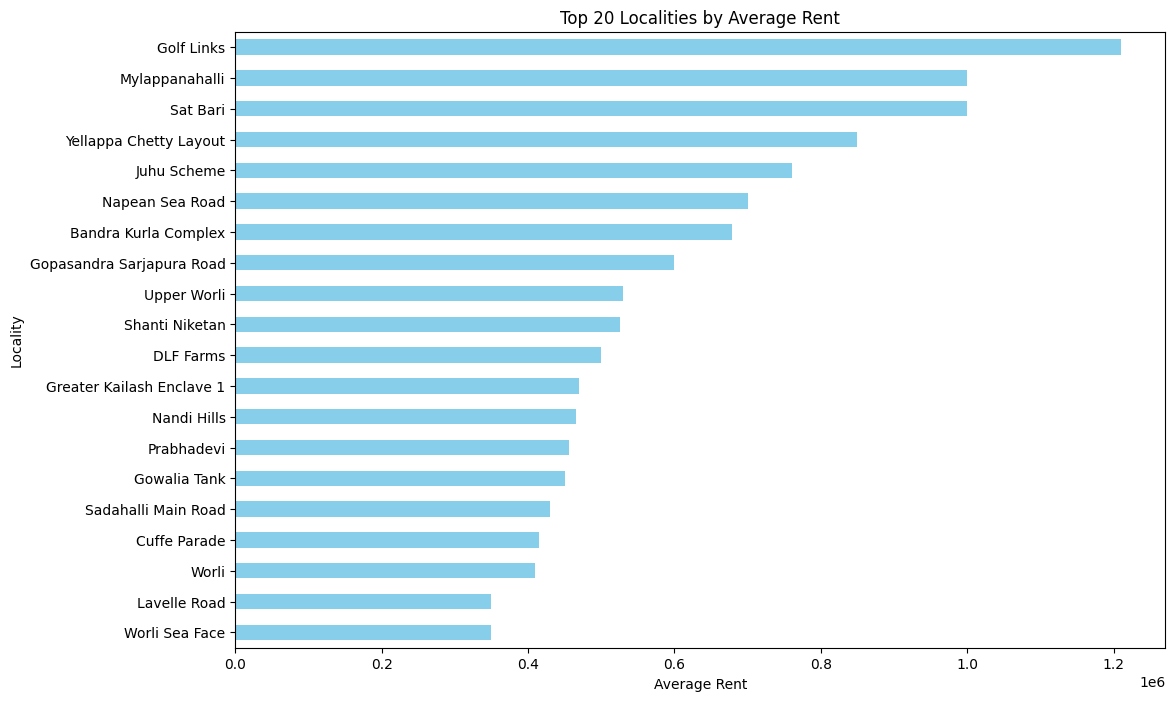

In [ ]:
# Localities have a large number of categories, so difficult to visualize

# Top 20 localities by average rent
top_localities = df.groupby('locality')['rent'].mean().nlargest(20)

plt.figure(figsize=(12, 8))
top_localities.plot(kind='barh', color='skyblue')
plt.xlabel("Average Rent")
plt.ylabel("Locality")
plt.title("Top 20 Localities by Average Rent")
plt.gca().invert_yaxis()  # Invert y-axis for readability
plt.show()

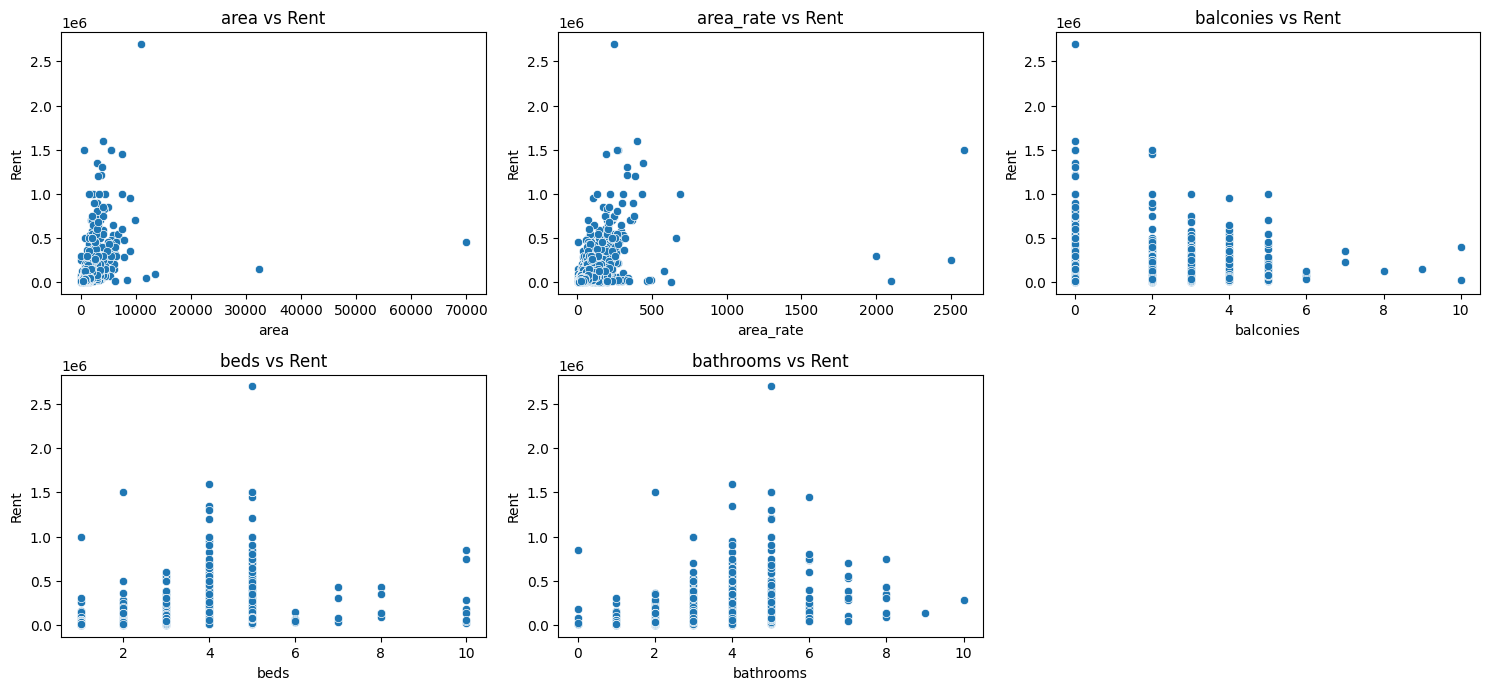

In [ ]:
# List of columns to compare with 'rent'
features_to_compare = ['area', 'area_rate', 'balconies', 'beds', 'bathrooms']

# Plot each feature against 'rent'
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_compare,1):
    plt.subplot(3, 3, i)  # Adjust layout as needed
    sns.scatterplot(data=df, x=feature, y='rent')
    plt.title(f"{feature} vs Rent")
    plt.xlabel(feature)
    plt.ylabel("Rent")
plt.tight_layout()
plt.show()

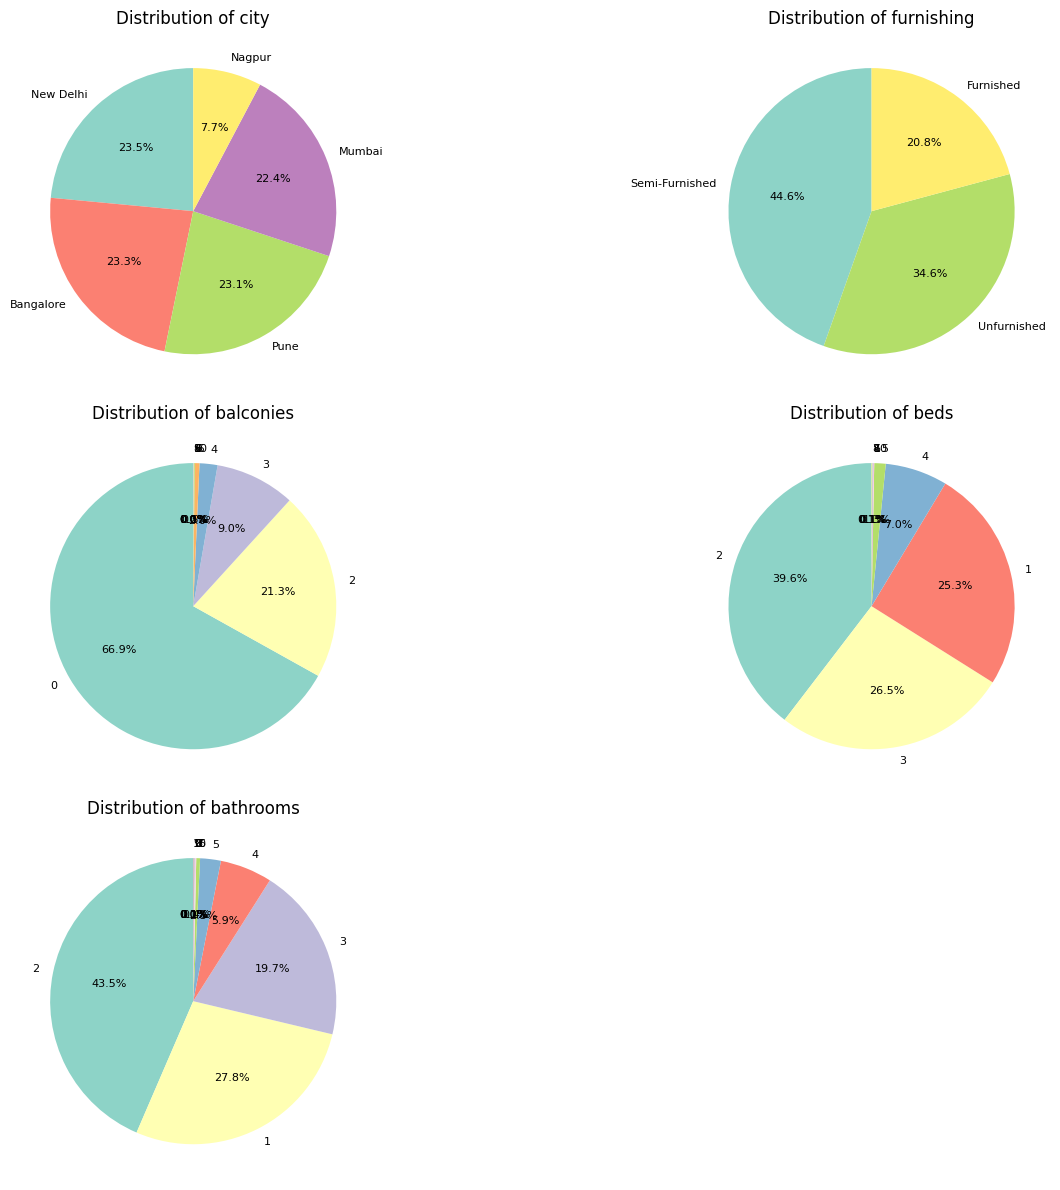

In [ ]:
features_pie = ['city', 'furnishing', 'balconies', 'beds', 'bathrooms']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(features_pie, 1):
    plt.subplot(3, 2, i)
    df[feature].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Set3',textprops={'fontsize': 8})
    plt.title(f"Distribution of {feature}")
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(df, x='beds', y='bathrooms', z='balconies', color='rent', size='area',
        title='Room Configuration Distribution',
        labels={
            'beds': 'Bedrooms',
            'bathrooms': 'Bathrooms',
            'balconies': 'Balconies',
            'rent': 'Monthly Rent (₹)'
        },
        color_continuous_scale=px.colors.sequential.Viridis_r,
        width=1500,
        height=800
    )
fig.show()

<ipython-input-29-8ce7b609531f>:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




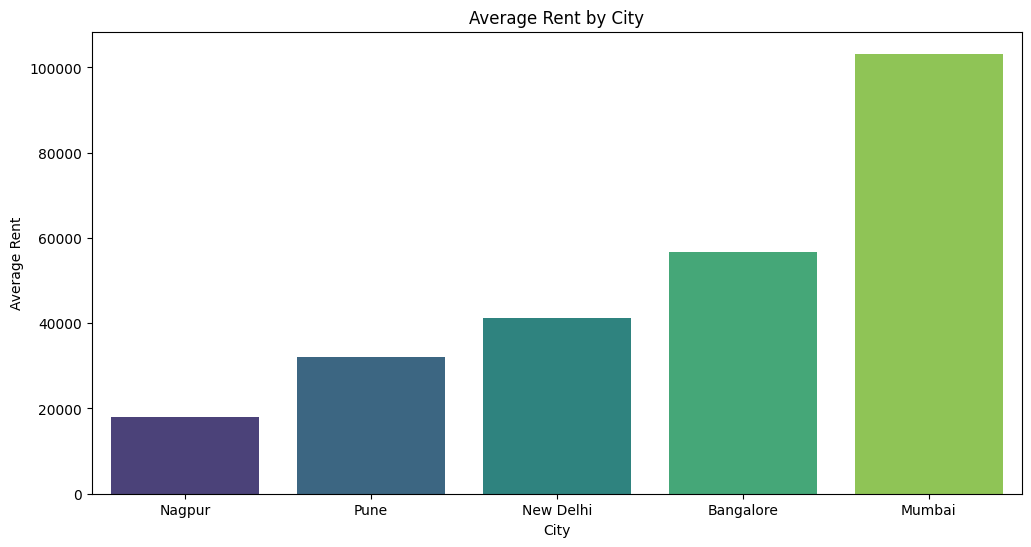

In [ ]:
# Calculate average rent per city
city_rent_avg = df.groupby('city')['rent'].mean().sort_values()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=city_rent_avg.index, y=city_rent_avg.values, palette="viridis")
plt.title("Average Rent by City")
plt.xlabel("City")
plt.ylabel("Average Rent")
plt.show()

### Data Preprocessing

In [ ]:
# Create a copy of the DataFrame
df_copy = df.copy()
df_copy.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0


Treating outliers:-

In [ ]:
def replace_outliers_with_median(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    median = df[column].median()
    # Replace outliers with the median
    df[column] = np.where(
        (df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR),
        median,
        df[column]
    )

In [ ]:
# Apply replacement for each column
for col in ['area', 'area_rate', 'rent']:
    replace_outliers_with_median(df_copy, col)

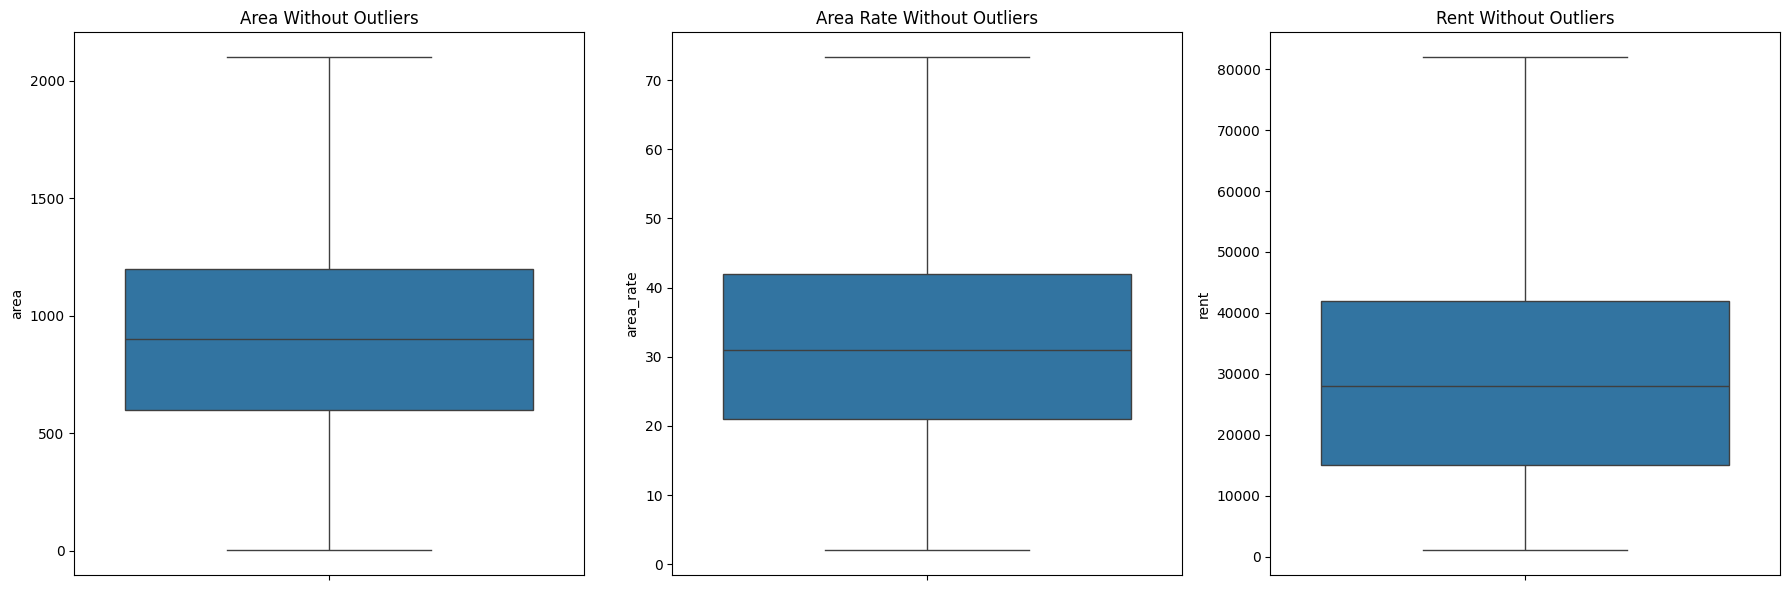

In [ ]:
# Boxplots without showing outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=df_copy, y='area', ax=axes[0], showfliers=False)
axes[0].set_title("Area Without Outliers")

sns.boxplot(data=df_copy, y='area_rate', ax=axes[1], showfliers=False)
axes[1].set_title("Area Rate Without Outliers")

sns.boxplot(data=df_copy, y='rent', ax=axes[2], showfliers=False)
axes[2].set_title("Rent Without Outliers")

plt.tight_layout()
plt.show()

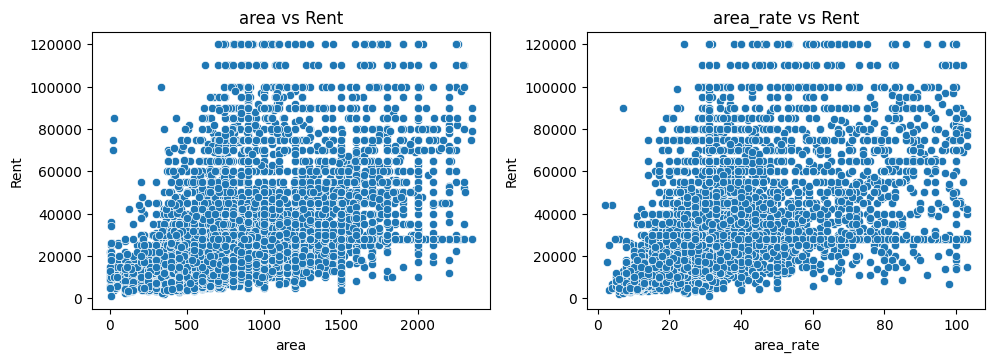

In [ ]:
# List of columns to compare with 'rent'
features_to_compare = ['area', 'area_rate']

# Plot each feature against 'rent'
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_compare,1):
    plt.subplot(3, 3, i)  # Adjust layout as needed
    sns.scatterplot(data=df_copy, x=feature, y='rent')
    plt.title(f"{feature} vs Rent")
    plt.xlabel(feature)
    plt.ylabel("Rent")
plt.tight_layout()
plt.show()

Treating high cardinality variable - locality

Locality is a high cardinality categorical variable and 50% of the categories have only 1 occurance.

In [ ]:
# locality_counts = df_copy['locality'].value_counts()
# # Filter localities with at least 10 occurrences
# top_localities = locality_counts[locality_counts >= 20]

# # Replace rare localities with 'Other'
# df_copy['locality'] = df_copy['locality'].apply(lambda x: x if x in top_localities else 'Other')

# No significant reduction observed

In [ ]:
# Target Encoding

# Calculate the mean rent per locality
locality_rent_mean = df_copy.groupby('locality')['rent'].mean()

# Map these values back to the dataset
df_copy['locality'] = df_copy['locality'].map(locality_rent_mean)

Separating feature and target variables:-

In [ ]:
X = df_copy[['city', 'locality', 'area', 'beds', 'bathrooms', 'balconies', 'furnishing', 'area_rate']]
y = df_copy['rent']

X.head()

,city,locality,area,beds,bathrooms,balconies,furnishing,area_rate
0,Mumbai,39500.000000,897.0,2,2,0,Semi-Furnished,31.0
1,Mumbai,43850.000000,490.0,1,1,0,Semi-Furnished,31.0
2,Pune,24153.846154,550.0,1,1,0,Unfurnished,22.0
3,Nagpur,9625.000000,1000.0,2,2,0,Unfurnished,8.0
4,Mumbai,23231.818182,595.0,1,1,0,Unfurnished,25.0


Train test split:-

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=X['city'])

Encoding:-

In [ ]:
# Encode categorical features using LabelEncoder
le_furnish = LabelEncoder()

X_train['furnishing'] = le_furnish.fit_transform(X_train['furnishing'])
X_test['furnishing'] = le_furnish.transform(X_test['furnishing'])

In [ ]:
# Get the class-to-encoded label mapping
class_mapping = dict(zip(le_furnish.classes_, le_furnish.transform(le_furnish.classes_)))
print("Furnishing to Encoded Label Mapping:")
print(class_mapping)

Furnishing to Encoded Label Mapping:
{'Furnished': 0, 'Semi-Furnished': 1, 'Unfurnished': 2}


In [ ]:
le_city = LabelEncoder()
X_train['city'] = le_city.fit_transform(X_train['city'])
X_test['city'] = le_city.transform(X_test['city'])

In [ ]:
# Get the class-to-encoded label mapping
class_mapping = dict(zip(le_city.classes_, le_city.transform(le_city.classes_)))
print("Furnishing to Encoded Label Mapping:")
print(class_mapping)

Furnishing to Encoded Label Mapping:
{'Bangalore': 0, 'Mumbai': 1, 'Nagpur': 2, 'New Delhi': 3, 'Pune': 4}


In [ ]:
X_train.head()

,city,locality,area,beds,bathrooms,balconies,furnishing,area_rate
3068,0,47680.372549,1200.0,3,3,2,1,50.0
3599,2,11650.000000,1300.0,3,2,0,2,9.0
7374,4,23666.666667,675.0,1,1,0,1,24.0
3168,1,41320.512821,759.0,2,3,0,0,31.0
6988,0,38705.882353,1400.0,3,3,0,0,61.0


In [ ]:
X_test.head()

,city,locality,area,beds,bathrooms,balconies,furnishing,area_rate
4110,1,58500.000000,709.0,2,2,0,2,31.0
3299,0,47666.666667,600.0,2,1,0,2,13.0
7223,2,12625.000000,210.0,1,1,0,1,19.0
3948,1,51132.075472,950.0,3,3,0,2,84.0
5655,2,17045.454545,500.0,1,1,2,1,14.0


In [ ]:
scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [ ]:
target_scaler = StandardScaler()

# Scale the target variable (y_train)
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

## Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the linear regression model
model = LinearRegression()

# Fit the model on the training data
model.fit(scaled_X_train, y_train_scaled)

LinearRegression()

In [ ]:
# Make predictions on both training and test sets
y_train_pred = model.predict(scaled_X_train)
y_test_pred = model.predict(scaled_X_test)

In [ ]:
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

train_rmse = mean_squared_error(y_train_scaled, y_train_pred, squared=False)
test_rmse = mean_squared_error(y_test_scaled, y_test_pred, squared=False)
train_r2 = r2_score(y_train_scaled, y_train_pred)
test_r2 = r2_score(y_test_scaled, y_test_pred)

print("Training RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Training R^2:", train_r2)
print("Test R^2:", test_r2)

Training RMSE: 0.6357173894920674
Test RMSE: 0.5917511779533245
Training R^2: 0.5958634006973911
Test R^2: 0.6503588200804533


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Ridge Regression:-

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define the model
ridge = Ridge()

# Define the parameters grid
param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0]  # Alpha controls the regularization strength
}

# Initialize GridSearchCV with the model and parameter grid
ridge_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')

# Fit the model on the training data
ridge_search.fit(scaled_X_train, y_train_scaled)

print("Best parameters:", ridge_search.best_params_)

Best parameters: {'alpha': 10.0}


In [ ]:
# Get the best model
best_ridge_model = ridge_search.best_estimator_
print("Best model:", best_ridge_model)

Best model: Ridge(alpha=10.0)


In [ ]:
y_pred_scaled = best_ridge_model.predict(scaled_X_test)

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_scaled, y_pred_scaled)
print("R-squared:", r2)

R-squared: 0.6100072632781885


Lasso Regression:-

In [ ]:
from sklearn.linear_model import Lasso

# Define the model
lasso = Lasso()

# Define the parameters grid
param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0]  # Adjust alpha values based on your data and need for regularization
}

# Initialize GridSearchCV with the model and parameter grid
lasso_search = GridSearchCV(lasso, param_grid, cv=5, scoring='r2')

# Fit the model on the training data
lasso_search.fit(scaled_X_train, y_train_scaled)

# Get the best model
best_lasso_model = lasso_search.best_estimator_

print("Best parameters:", lasso_search.best_params_)
print("Best model:", best_lasso_model)

Best parameters: {'alpha': 0.01}
Best model: Lasso(alpha=0.01)


In [ ]:
y_pred_scaled = best_lasso_model.predict(scaled_X_test)

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_scaled, y_pred_scaled)
print("R-squared:", r2)

R-squared: 0.6093219742701527


## Support Vector Regressor

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Initialize the SVR model
svr = SVR()

# Define parameter grid for hyperparameter tuning
param_grid = {
    'kernel': ['linear', 'poly', 'rbf'],  # Different types of kernels
    'C': [0.1, 1, 10],               # Regularization parameter
    'epsilon': [0.1, 0.2],           # Epsilon in the loss function
    'gamma': ['scale', 'auto']            # Kernel coefficient (affects decision boundary)
}

# Initialize RandomizedSearchCV with cross-validation
grid_search = GridSearchCV(estimator=svr, param_grid=param_grid, cv=5, n_jobs=-1, scoring='r2')

# Fit the grid search to the training data
grid_search.fit(scaled_X_train, y_train_scaled)

# Best parameters from GridSearchCV
print("Best Parameters:", grid_search.best_params_)
# Best Parameters: {'kernel': 'linear', 'gamma': 'scale', 'epsilon': 0.2, 'C': 0.1} random
# Best Parameters: {'C': 10, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'} grid search

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Parameters: {'C': 10, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}


In [ ]:
# Predict with the best model found by GridSearchCV
y_train_pred_scaled = grid_search.predict(scaled_X_train)
y_test_pred_scaled = grid_search.predict(scaled_X_test)

In [ ]:
# Evaluate the model performance
train_r2 = r2_score(y_train_scaled, y_train_pred_scaled)
test_r2 = r2_score(y_test_scaled, y_test_pred_scaled)

print("Training R^2:", train_r2)
print("Test R^2:", test_r2)

Training RMSE: 0.6357173894920674
Test RMSE: 0.5917511779533245
Training R^2: 0.5958634006973911
Test R^2: 0.6503588200804533


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Initialize the Decision Tree Regressor model
dt_regressor = DecisionTreeRegressor(random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [None, 10, 20, 30, 40, 50],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],         # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],           # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2'],  # Number of features to consider for the best split
    'criterion': ['mse', 'friedman_mse', 'mae'],  # Function to measure quality of a split
    'splitter': ['best', 'random'],          # Strategy used to split at each node
}

# Initialize GridSearchCV with cross-validation and scoring
grid_search = GridSearchCV(estimator=dt_regressor, param_grid=param_grid, cv=5, n_jobs=-1, scoring='r2')

# Fit the grid search to the training data
grid_search.fit(scaled_X_train, y_train_scaled)

# Best parameters from GridSearchCV
print("Best Parameters:", grid_search.best_params_)

# Best Parameters: {'criterion': 'friedman_mse', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'best'}

Best Parameters: {'criterion': 'friedman_mse', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'best'}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
3240 fits failed out of a total of 4860.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
907 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ut

In [ ]:
# Predict with the best model found by GridSearchCV
y_train_pred_scaled = grid_search.predict(scaled_X_train)
y_test_pred_scaled = grid_search.predict(scaled_X_test)

In [ ]:
# Evaluate the model performance
train_rmse = mean_squared_error(y_train_scaled, y_train_pred_scaled, squared=False)
test_rmse = mean_squared_error(y_test_scaled, y_test_pred_scaled, squared=False)
train_r2 = r2_score(y_train_scaled, y_train_pred_scaled)
test_r2 = r2_score(y_test_scaled, y_test_pred_scaled)

print("Training RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Training R^2:", train_r2)
print("Test R^2:", test_r2)

Training RMSE: 0.40014613355680245
Test RMSE: 0.5067541886793474
Training R^2: 0.8398830717995416
Test R^2: 0.7435876085475762


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Initialize the Random Forest Regressor model
rf_regressor = RandomForestRegressor(random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200, 500],           # Number of trees in the forest
    'max_depth': [None, 10, 20, 30, 40, 50],       # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],               # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],                 # Minimum samples required at each leaf node
    'max_features': ['auto', 'sqrt', 'log2']       # Number of features to consider for the best split
}

# Initialize GridSearchCV with cross-validation and scoring
grid_search = GridSearchCV(estimator=rf_regressor, param_grid=param_grid, cv=5, n_jobs=-1, scoring='r2')

# Fit the grid search to the training data
grid_search.fit(scaled_X_train, y_train_scaled)

# Best parameters from GridSearchCV
print("Best Parameters:", grid_search.best_params_)
# Best Parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
1080 fits failed out of a total of 3240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
464 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py

Best Parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
# Predict with the best model found by GridSearchCV
y_train_pred_scaled = grid_search.predict(scaled_X_train)
y_test_pred_scaled = grid_search.predict(scaled_X_test)

In [ ]:
# Evaluate the model performance
train_r2 = r2_score(y_train_scaled, y_train_pred_scaled)
test_r2 = r2_score(y_test_scaled, y_test_pred_scaled)

print("Training R^2:", train_r2)
print("Test R^2:", test_r2)

Training R^2: 0.9454573022852227
Test R^2: 0.8540238685330614
